<a href="https://colab.research.google.com/github/sabithakrishnan/multimodal-image-analysis/blob/main/Multimodalimage_recognition_clip%26structuredPrompt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install open-clip-torch datasets pillow torch torchvision matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00


In [ ]:
import os
from pathlib import Path
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm

class ProductionDatasetBuilder:
    def __init__(self, dataset_repo: str = "blanchon/EuroSAT_RGB"):
        self.repo = dataset_repo

    def build_local_directory(self, output_dir: str = "satellite_dataset"):
        dest_path = Path(output_dir)

        # Guard clause: avoid re-running if data exists
        if dest_path.exists() and any(dest_path.iterdir()):
            print(f"📦 Workspace directory '{output_dir}' already exists. Transitioning steps...")
            return

        print(f"📡 Accessing Hugging Face native parquet tables for '{self.repo}'...")
        # Loads clean tabular shards; completely bypasses legacy python execution scripts
        dataset_split = load_dataset(self.repo, split="train")

        # Dynamically infer the land-use taxonomy from the Metadata Table schema
        label_names = dataset_split.features["label"].names
        print(f"🎯 Verified {len(label_names)} target categories for extraction.")

        print("\n💾 Unpacking and storing satellite tensors to local filesystems...")
        for idx, sample in enumerate(tqdm(dataset_split, desc="Processing Satellite Tiles")):
            pil_img = sample["image"]
            label_id = sample["label"]

            # Sanitize naming structures to eliminate runtime mapping mistakes
            class_name = label_names[label_id].replace(" ", "")

            # Map path structure: satellite_dataset/IndustrialBuildings/tile_x.jpg
            class_folder = dest_path / class_name
            class_folder.mkdir(parents=True, exist_ok=True)

            file_name = class_folder / f"tile_{idx}.jpg"

            if pil_img.mode != "RGB":
                pil_img = pil_img.convert("RGB")

            pil_img.save(file_name, "JPEG")

        print(f"\n✅ Step 2 Complete! File mapping successfully resolved inside: '{dest_path.resolve()}'")

if __name__ == "__main__":
    builder = ProductionDatasetBuilder()
    builder.build_local_directory()


📡 Accessing Hugging Face native parquet tables for 'blanchon/EuroSAT_RGB'...


README.md:   0%|          | 0.00/3.38k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  105MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 34.8MB            

...

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

🎯 Verified 10 target categories for extraction.

💾 Unpacking and storing satellite tensors to local filesystems...


Processing Satellite Tiles: 100%|██████████| 16200/16200 [00:18<00:00, 892.21it/s] 


✅ Step 2 Complete! File mapping successfully resolved inside: '/content/satellite_dataset'


⚡ Evaluating satellite tiles with engineered anchors...


Processing Batches: 100%|██████████| 254/254 [01:29<00:00,  2.84it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

🧮 --- Manual Macro-Averaged Calculations ---
Accuracy: 0.8875
Precision: 0.4274
Recall:    0.4458
F1-Score:  0.3761


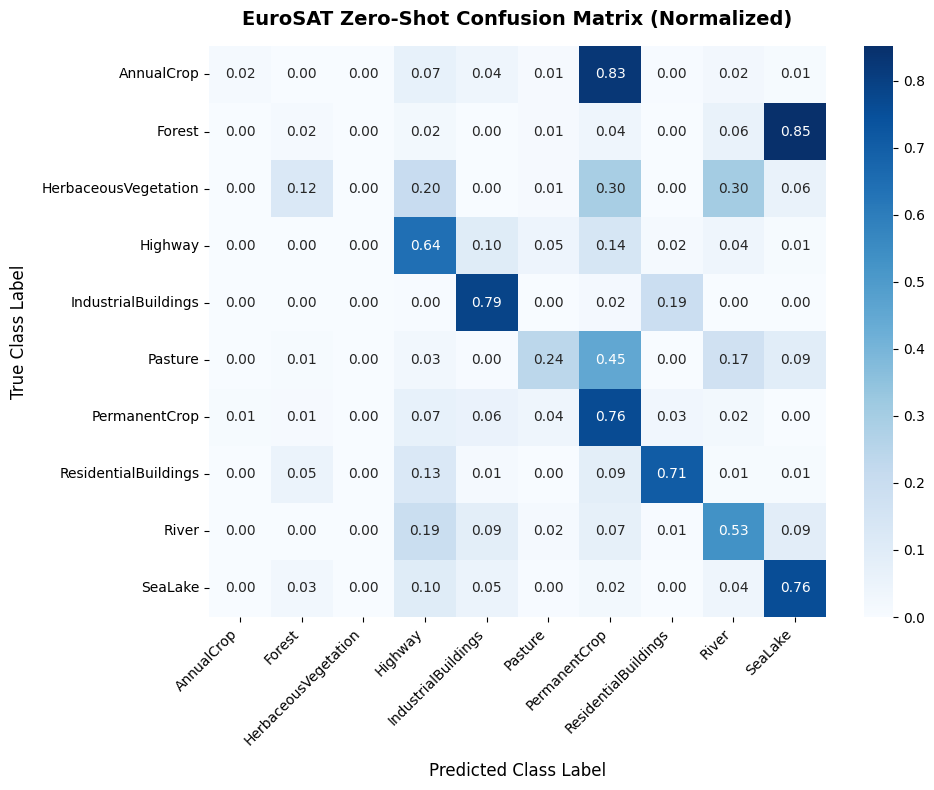

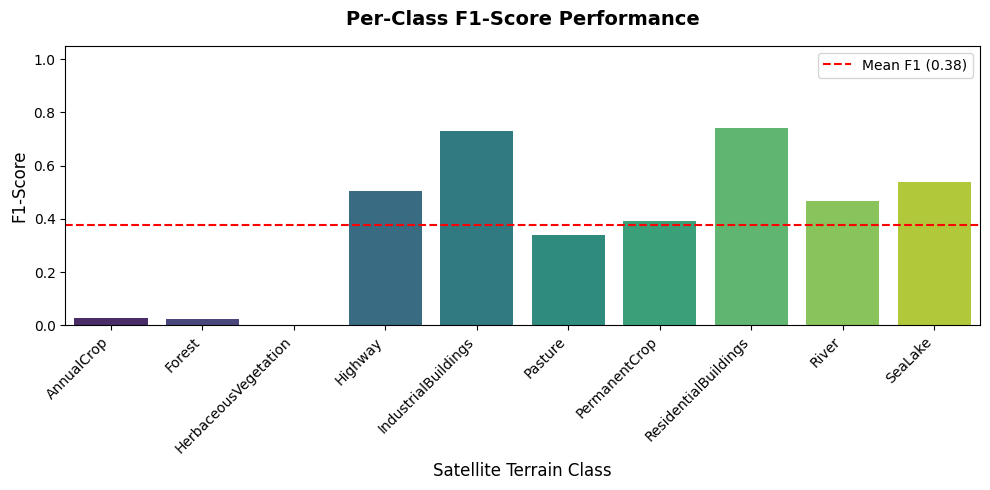

💾 F1-Score chart saved as 'per_class_f1_scores.png'


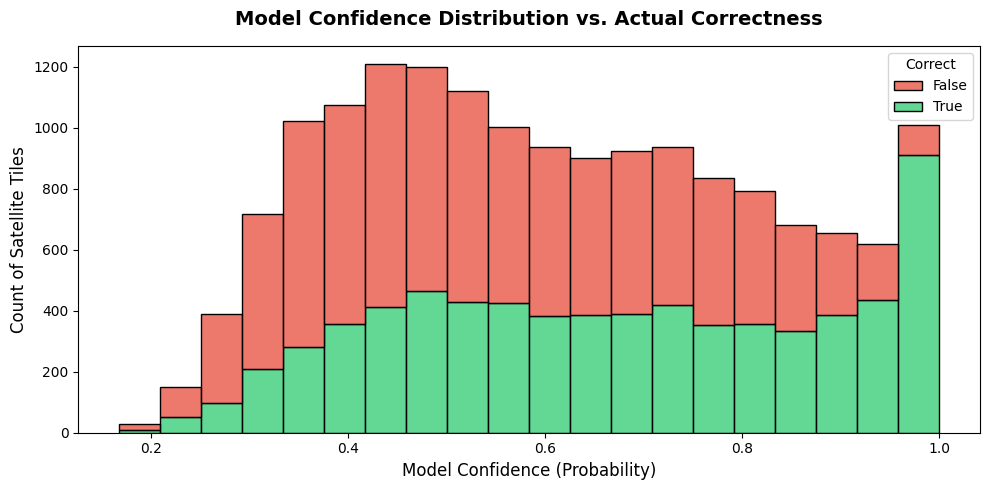

In [ ]:
import torch
import open_clip
import numpy as np
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


def get_geospatial_ensemble(class_name: str) -> list[str]:
    name = class_name.lower()

    if name == "annualcrop":
        return [
            "a satellite view of cultivated agricultural crop fields",
            "aerial photography of farmed fields with visible crop rows",
            "an overhead patch of active agricultural farmland"
        ]
    elif name == "herbaceousvegetation":
        return [
            "a satellite photo of wild grass and low green shrubs",
            "an aerial view of open unmanaged green grasslands",
            "natural green vegetation fields from a top-down view"
        ]
    elif name == "industrialbuildings":
        return [
            "an overhead satellite photo of large industrial warehouses",
            "a bird's eye view of commercial factories and large gray metal roofs",
            "satellite imagery of logistics buildings and industrial complexes"
        ]
    elif name == "residentialbuildings":
        return [
            "a satellite photograph of suburban houses and neighborhood streets",
            "an overhead aerial view of high-density residential rooftops",
            "satellite view of clusters of homes and residential housing"
        ]
    elif name == "sealake":
        return [
            "a satellite image of a large open blue water body",
            "an overhead view of a deep blue lake or ocean surface water",
            "aerial photography of calm open sea water texturing"
        ]
    else:
        return [
            f"a satellite photograph of {name} terrain",
            f"an aerial top-down view of a {name} region",
            f"a high-resolution satellite tile showing a {name} environment"
        ]

if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    data_directory = "satellite_dataset"

    # Initialize Network
    model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k', device=device)
    tokenizer = open_clip.get_tokenizer('ViT-B-32')
    #Make the model to evaluation (testing mode)
    model.eval()

    # Setup Data Loader using standard ImageFolder dataset. Assigning transform with preprocess makes the input image compatible with the neural network clip used
    dataset = ImageFolder(root=data_directory, transform=preprocess)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

    #Disabling the gradient fuction so that only inferences are made
    ensemble_features_list = []
    with torch.no_grad():
        for cls in dataset.classes:
            phrases = get_geospatial_ensemble(cls)
            tokens = tokenizer(phrases).to(device)

            phrase_embeddings = model.encode_text(tokens)
            phrase_embeddings /= phrase_embeddings.norm(dim=-1, keepdim=True)

            mean_class_embedding = phrase_embeddings.mean(dim=0)
            mean_class_embedding /= mean_class_embedding.norm(dim=-1)

            ensemble_features_list.append(mean_class_embedding)

        text_features = torch.stack(ensemble_features_list)

    #Evaluation Loop Containers
    all_predictions = []
    all_targets = []
    all_confidences = []
    all_correctness = []
    amp_dtype = torch.float16
    print("⚡ Evaluating satellite tiles with engineered anchors...")
    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Processing Batches"):
            images = images.to(device)

            # Extract features on GPU
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            # Compute similarities
            logits = 100.0 * image_features @ text_features.T
            probs = logits.softmax(dim=-1)

            # Use the exact same argmax for both variables
            max_probs, preds = probs.max(dim=-1)

            # Extend metrics arrays correctly using .cpu()
            all_predictions.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())
            all_confidences.extend(max_probs.cpu().numpy())
            all_correctness.extend((preds == targets.to(device)).cpu().numpy())


    # Compute and normalize the matrix
    cm = confusion_matrix(all_targets, all_predictions)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    #compute classification report and extract per class F1 score
    report_dict = classification_report(all_targets, all_predictions, target_names=dataset.classes, output_dict=True)
    classes = dataset.classes
    f1_scores = [report_dict[cls]['f1-score'] for cls in classes]
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN= np.sum(cm) - (FP + FN + TP)
    total_samples = np.sum(cm)
# Adding a small epsilon (1e-7) prevents "division by zero" errors
    class_accuracy  = (TP +TN) / (TP+TN+FP+FN)
    class_precision = TP / (TP + FP + 1e-7)
    class_recall    = TP / (TP + FN + 1e-7) # Equivalent to Sensitivity
    class_f1        = 2 * (class_precision * class_recall) / (class_precision + class_recall + 1e-7)

# --- Global Macro-Averaging ---
    accuracy  = np.mean(class_accuracy)
    precision = np.mean(class_precision)
    recall    = np.mean(class_recall)
    f1        = np.mean(class_f1)
    print(f"Accuracy: {accuracy:.4f}") # Overall match
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    # Create the heatmap plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=dataset.classes,
        yticklabels=dataset.classes,
        cbar=True
    )

    plt.title("EuroSAT Zero-Shot Confusion Matrix (Normalized)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Predicted Class Label", fontsize=12, labelpad=10)
    plt.ylabel("True Class Label", fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    # Plot F1-Scores
    plt.figure(figsize=(10, 5))
    sns.barplot(x=classes, y=f1_scores, palette="viridis")
    plt.axhline(y=np.mean(f1_scores), color='r', linestyle='--', label=f'Mean F1 ({np.mean(f1_scores):.2f})')
    plt.title("Per-Class F1-Score Performance", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Satellite Terrain Class", fontsize=12)
    plt.ylabel("F1-Score", fontsize=12)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print("💾 F1-Score chart saved as 'per_class_f1_scores.png'")
    # Plot Confidence Distribution broken down by True vs False predictions
    plt.figure(figsize=(10, 5))
    df_perf = {"Confidence": all_confidences, "Correct": all_correctness}
    sns.histplot(data=df_perf, x="Confidence", hue="Correct", multiple="stack", bins=20, palette={True: "#2ecc71", False: "#e74c3c"})
    plt.title("Model Confidence Distribution vs. Actual Correctness", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Model Confidence (Probability)", fontsize=12)
    plt.ylabel("Count of Satellite Tiles", fontsize=12)
    plt.tight_layout()
    plt.show()


